<a href="https://colab.research.google.com/github/mmierzwa2002/SI_lab/blob/main/lab1/lab1_si.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [2]:
observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))
inputs = np.column_stack((xs,zs))
print(inputs.shape)

(1000, 2)


In [3]:
noise = np.random.uniform(low=-1, high = 1, size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


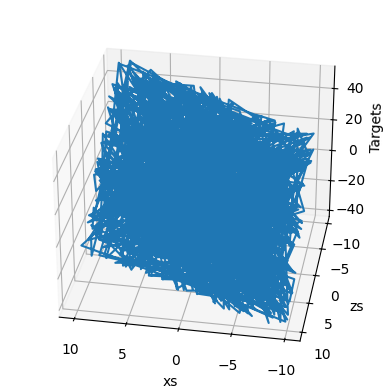

In [4]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [7]:
init_range = 0.1
weights = np.random.uniform(low=-init_range,high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range, size=1)
print(weights, biases)

[[-0.05264613]
 [-0.00428328]] [-0.00484439]


In [8]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

232.56479688512957
35.28482620376506
14.205986763925626
11.589100907761294
10.921458043737202
10.473511032443595
10.063519575148486
9.671856246981909
9.295897374686973
8.934823151866613
8.58802433948001
8.254934455168566
7.9350113669226765
7.627734578064705
7.332604188256299
7.04914006006757
6.776881035743431
6.515384186740459
6.264224093118925
6.0229921514396905
5.791295910021563
5.568758430475556
5.355017674477197
5.149725914779221
4.952549169506487
4.763166658812697
4.581270283015061
4.406564121357869
4.238763950589508
4.077596782569754
3.9228004201550557
3.7741230306393074
3.631322736056168
3.494167219676379
3.36243334805993
3.235906808048183
3.1143817581054067
2.9976604934424915
2.8855531243780415
2.7778772674136
2.6744577485204095
2.5751263181550015
2.4797213775399887
2.3880877157647573
2.3000762572783353
2.215543819363681
2.134352879198802
2.0563713501257572
1.9814723667635634
1.9095340786154114
1.8404394518344172
1.7740760788254177
1.7103359953730377
1.6491155049985435
1.590315

In [9]:
print (weights, biases)

[[ 2.00631009]
 [-2.9937105 ]] [4.33240341]


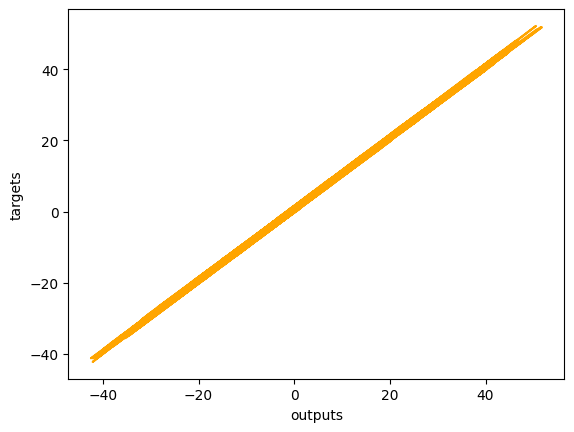

In [10]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()